# Chain

## Review
We built a simple graph (`simple_graph.ipynb`) with nodes, normal edges, and conditional edges.

## Goals
Now, let's build up to a simple chain that combines 4 concepts.
- Using chat messages as our graph state;
- Using chat models in graph nodes;
- Binding tools to our chat model;
- Executing tool calls in graph nodes;

## Messages
Chat models can use messages, which capture different roles within a conversation.
LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. These represent a message from the user, from chat model, for the chat model to instruct behavior and from a tool call.

Let's create a list of messages. Each message can be supplied with a few things:
- `content` - content of the message;
- `name` - optionally, a message author;
- `response_metadata` - optionally, a dict of metadata;

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.", name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about?", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about?
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in US.


## Chat Models
Chat Models use a sequence of messages as input and support message types, as discussed above. 

In [2]:
# Import libraries
import os, getpass
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)
result = llm.invoke(messages)
print(result)
print(result.response_metadata)

content='If you\'re looking for the best place to see orcas in the U.S., hands down the top spot is the **San Juan Islands in Washington State**. This area is world-famous for reliable sightings, with the peak season running roughly from May through October.\n\nHere’s a breakdown of the best locations and what makes each one special:\n\n### 1. The San Juan Islands, Washington (The Gold Standard)\nThis is your best bet for a few reasons. You can see both fish-eating **Southern Resident orcas** (the endangered J, K, and L pods) and mammal-eating **Bigg’s (transient) orcas**, which are booming in population.\n\n- **Lime Kiln Point State Park (San Juan Island):** Known as "Whale Watch Park," this is one of the few places on Earth you can reliably watch orcas from the shore. Bring a picnic, sit on the rocky bluffs, and wait for them to swim by, often within 50 feet.\n- **Boat Tours (departing from Friday Harbor, Anacortes, or Port Townsend):** The surest way to see them. Most tour operators

## Tools
Tools are useful whenever you want a model to interact with external systems. External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. When we bind an API, for example, as a tool we given the model awareness of the required input schema. The model will choose to call a tool based on the natural language input from the user. And it will return an output that adheres to the tool's schema.


Many LLM providers support tool calling and tool calling interface in LangChain is simple. You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

In [3]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3?", name="Lance")])
tool_call.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_00_Q3QVyO6S4Hg5uiEviIWR1608)
 Call ID: call_00_Q3QVyO6S4Hg5uiEviIWR1608
  Args:
    a: 2
    b: 3


## Using Messages as State
With these foundations in place, we can now use messages in our graph state. 

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`. `messages` is simply a list of messages, as we defined above.

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built `MessagesState`.
- With a pre-build single `message` key;
- This is a list of `AnyMessage` object;
- It uses the `add_messages` reducer;

In [5]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    pass

# Initial State
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")]
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")
messages_states = add_messages(initial_messages, new_message)

for m in messages_states:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

Hello! How can I assist you?
================================ Human Message =================================
Name: Lance

I'm looking for information on marine biology.
================================== Ai Message ==================================
Name: Model

Sure, I can help with that. What specifically are you interested in?


## Our Graph
Now, let's use `MessagesState` with a graph.

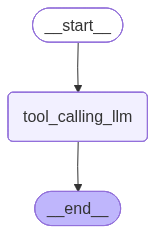

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_00_VD0M89ddZrb04DsE8vA00216)
 Call ID: call_00_VD0M89ddZrb04DsE8vA00216
  Args:
    a: 2
    b: 3
